In [43]:
##### IMPORTS

import os
os.environ['picaso_refdata'] = r'C:\Users\Alex\Desktop\Picaso\picaso\reference' # THIS MUST GO BEFORE YOUR IMPORT STATEMENT
os.environ['PYSYN_CDBS'] = r'C:\Users\Alex\Desktop\Picaso\grp\redcat\trds' # This is for the stellar data discussed below.

# General
import pickle
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt

from pathlib import Path
from itertools import product
from scipy.interpolate import RegularGridInterpolator

# Picaso and Virga
from picaso import justdoit as jdi

In [44]:
##### CONFIGURATIONS

# Directories
sonor_path  = r'C:\Users\Alex\Desktop\Picaso\data\sonora' # Sonora db
# sonor_path  = '/groups/tkaralidi/pbraunschweig/training_set/profiles/'
opaci_path  = None # Opacity db
# opcai_path  = '/groups/tkaralidi/opacity_500k_for_R5000_egpoutput.db'
pickl_path  = r"C:\Users\Alex\Desktop\Picaso\NN_project\cloudy_spectra_code\bobcat_to_diamondback.pickle"
# pickl_path  = "home/al864695/pickle"

In [45]:
##### PICKLE TRIAL AND ERROR

# The pickle is a numpy array of shape [301, 41, 5, 91]
# From Theodora code
# 301 corresponds to teff from [900, 2400] at 5 K steps
# 41 corresponds to logg from [3.50, 5.50] at 0.05 steps
# 5 corresponds to fsed from [1, 2, 3, 4, 8]
# 91 corresponds to 91 layers
# Each entry is a temp? correction factor for that layer

# Load and define axes
corrp  = pickle.load(open(pickl_path, "rb"))           # shape (301, 41, 5, 91)
taxis  = np.arange(900.0, 2405.0, 5.0)                 # 900..2400 (step 5)
gaxis  = np.round(np.arange(3.50, 5.54, 0.05), 3)      # 3.50..5.50 (step 0.05)
faxis  = np.array([1.0, 2.0, 3.0, 4.0, 8.0])           # fsed axis

# Pickle interpolation is still discrete?
# So for random sampling, it wouldn't quite work
# Or even out of range?

# Let's see
# Only fsed is not interpolated so that can be reference axis
# Do all sonora profiles have 91 layers?

def inject_corr(bd, Teff, logg, fsed):
    # For values like random sampling
    # Interpolate over Teff and log g at that fsed
    rgi = RegularGridInterpolator((taxis, gaxis), corrp[:, :, fi, :], bounds_error=True)

    # Interpolate
    corr = rgi((Teff, logg)).ravel()  # (91,)

    prof = bd.inputs["atmosphere"]["profile"]
    T = np.asarray(prof["temperature"], float)
    prof["temperature"] = (T * corr).tolist()

def inject_corr(bd, Teff, logg, fsed, clip_oob=True):
    """
    Apply Diamondback/Bobcat TP correction to PICASO inputs.
    Multiplies the current temperature profile by a correction factor
    interpolated over (Teff, logg) at nearest fsed.
    """
    # Choose the nearest fsed because since interpolation here
    fi = int(np.argmin(np.abs(faxis - float(fsed))))

    # Clip Teff/logg to grid so out of bound values still gets a correction
    # Extrapolation but we'll see
    Teff_in = float(np.clip(Teff, taxis[0], taxis[-1])) if clip_oob else float(Teff)
    logg_in = float(np.clip(logg, gaxis[0], gaxis[-1])) if clip_oob else float(logg)

    # For values like random sampling
    # Interpolate over Teff and log g at that fsed
    rgi = RegularGridInterpolator((taxis, gaxis),
                                  corrp[:, :, fi, :],
                                  bounds_error=not clip_oob,
                                  fill_value=None)
    
    # Interpolate
    corr = rgi((Teff_in, logg_in)).ravel()

    prof = bd.inputs["atmosphere"]["profile"]
    T    = np.asarray(prof["temperature"], float)
    prof["temperature"] = (T * corr).tolist()

In [46]:
##### TEST TP PROFILE NEW AND OLD

# Parameters
wav_range = [0.3, 5.0] # microns
Teff_s    = 600.0 # K
logg_s    = 4.50   # cgs
fsed_s    = 2.0
grav_s    = (10**logg_s) * 1e-2   # m s^-2

opa       = jdi.opannection(wav_range, opaci_path)
bd        = jdi.inputs(calculation="browndwarf")
bd.phase_angle(0)
bd.gravity(grav_s, gravity_unit=u.Unit('m s^-2'))
bd.sonora(sonor_path, Teff_s)

# TP PROFILE BEFORE
prof   = bd.inputs['atmosphere']['profile']
T_before = np.array(prof["temperature"], dtype=float)

# APPLY CORRECTION
_ = inject_corr(bd, Teff_s, logg_s, fsed_s)
T_after = np.array(prof["temperature"], dtype=float)

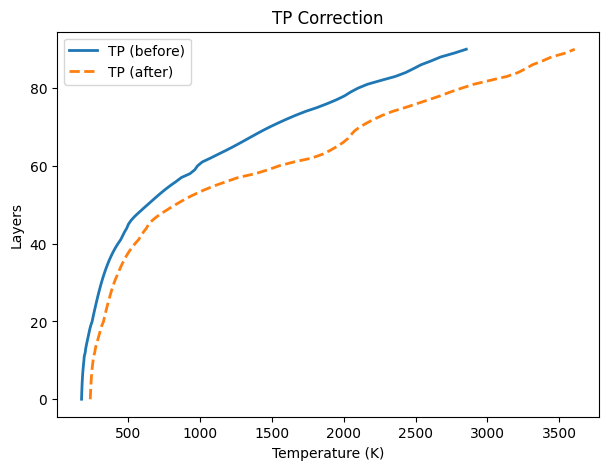

In [47]:
##### PLOT

layers = T_before.size
y = np.arange(layers)

plt.figure(figsize=(7, 5))
plt.plot(T_before, y, label="TP (before)", linewidth=2)
plt.plot(T_after,  y, label="TP (after)",  linewidth=2, linestyle="--")
plt.xlabel("Temperature (K)")
plt.ylabel("Layers")
plt.title("TP Correction")
plt.legend()
plt.show()